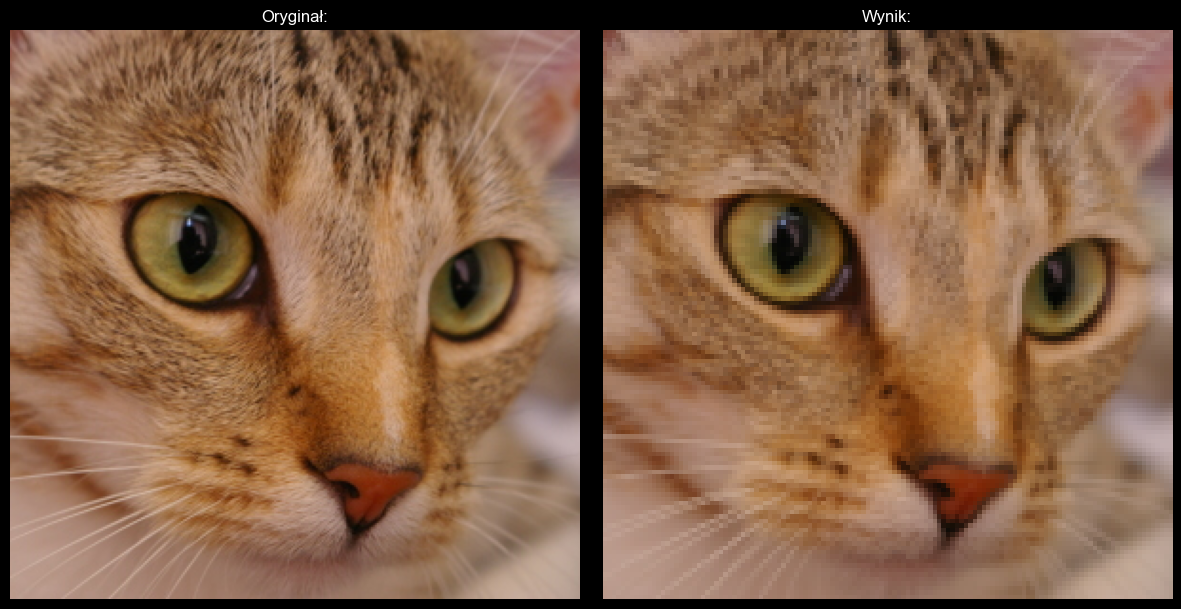

In [20]:
#Zadanie 1
import matplotlib.pyplot as plt
from skimage import data, transform
import numpy as np
cat_image = data.chelsea()
h, w, _ = cat_image.shape
min_dim = min(h, w)
start_h = (h - min_dim) // 2
start_w = (w - min_dim) // 2
cropped_cat = cat_image[start_h:start_h + min_dim, start_w:start_w + min_dim]
resized_cat = transform.resize(cropped_cat, (128, 128), anti_aliasing=True)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cropped_cat)
ax[0].set_title(f"Oryginał:")
ax[0].axis('off')
ax[1].imshow(resized_cat)
ax[1].set_title(f"Wynik:")
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [21]:
#Zadanie 2
from skimage import data, transform, color
astronaut_image = data.astronaut()
image_resized_example = transform.resize(astronaut_image, (128, 128), anti_aliasing=True)
astronaut_gray = color.rgb2gray(image_resized_example)
astronaut_flat = astronaut_gray.flatten()
print(f"Kształt wektora: {astronaut_flat.shape}")

Kształt wektora: (16384,)


In [22]:
#Zadanie 3
from sklearn.preprocessing import StandardScaler
X = astronaut_flat.reshape(1, -1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Średnia przeskalowanego wektora: {X_scaled.mean()}")
print(f"Odchylenie standardowe przeskalowanego wektora: {X_scaled.std()}")

Średnia przeskalowanego wektora: 0.0
Odchylenie standardowe przeskalowanego wektora: 0.0


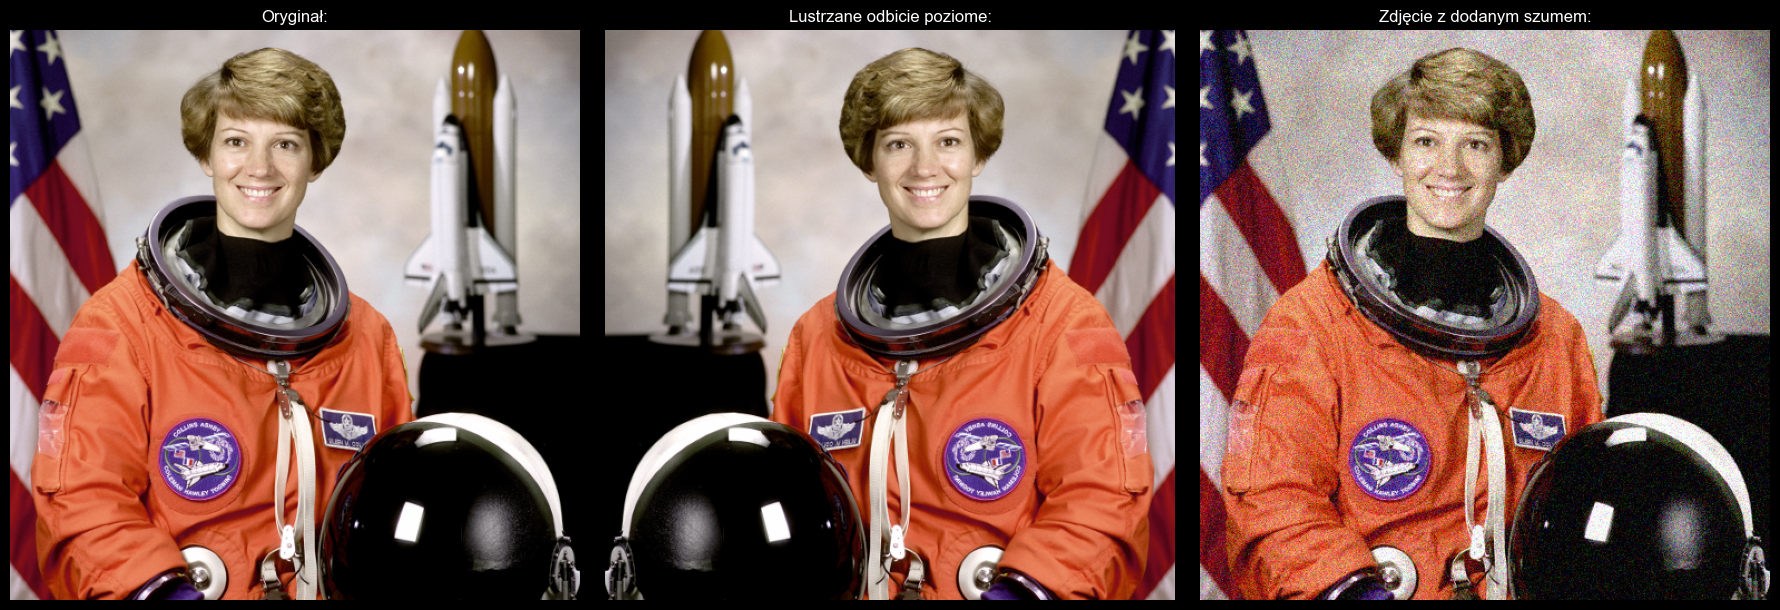

In [23]:
#Zadanie 4
from skimage import data, util
astro = data.astronaut()
astro_flipped = np.fliplr(astro)
astro_noisy = util.random_noise(astro)
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(astro)
ax[0].set_title("Oryginał:")
ax[0].axis('off')
ax[1].imshow(astro_flipped)
ax[1].set_title("Lustrzane odbicie poziome:")
ax[1].axis('off')
ax[2].imshow(astro_noisy)
ax[2].set_title("Zdjęcie z dodanym szumem:")
ax[2].axis('off')
plt.tight_layout()
plt.show()

Liczba komponentów zachowujących 90% wariancji: 0.9


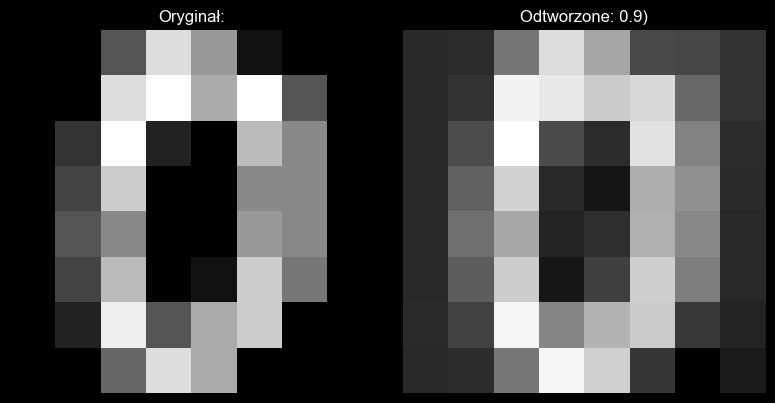

In [24]:
#Zadanie 5
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X)
n_comps = pca.n_components
print(f"Liczba komponentów zachowujących 90% wariancji: {n_comps}")
X_recovered = pca.inverse_transform(X_pca)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(X[0].reshape(8, 8), cmap='gray')
ax[0].set_title("Oryginał:")
ax[0].axis('off')
ax[1].imshow(X_recovered[0].reshape(8, 8), cmap='gray')
ax[1].set_title(f"Odtworzone: {n_comps})")
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [25]:
#Zadanie 6
import os
from skimage import data, transform, color, io
import random
from skimage import util
def flip_or_not_to_flip(img, prob=0.5):
    if random.random() < prob:
        return np.fliplr(img)
    return img
def gray_or_not_gray(img, prob=0.5):
    if random.random() < prob:
        if len(img.shape) == 3:
            return color.rgb2gray(img)
    return img
def center_crop_to_square(img):
    h, w = img.shape[:2]
    if h == w:
        return img
    min_dim = min(h, w)
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    return img[start_h:start_h+min_dim, start_w:start_w+min_dim]
def preprocess_images(img_names, target_size=(128, 128), output_dir='processed_images'):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Utworzono folder: {output_dir}")
    for name in img_names:
        try:
            img = getattr(data, name)()
            current_h, current_w = img.shape[:2]
            if (current_h, current_w) != target_size:
                img = center_crop_to_square(img)
                img = transform.resize(img, target_size, anti_aliasing=True)
            img = flip_or_not_to_flip(img, prob=0.5)
            img = gray_or_not_gray(img, prob=0.5)
            img_to_save = util.img_as_ubyte(img) if img.dtype != np.uint8 else img
            file_path = os.path.join(output_dir, f"{name}_processed.png")
            io.imsave(file_path, img_to_save)
            print(f"Przetworzono i zapisano: {name}")
        except Exception as e:
            print(f"Błąd podczas przetwarzania {name}: {e}")
img_list = ['rocket', 'astronaut', 'camera', 'cat', 'coffee']
preprocess_images(img_list, target_size=(256, 256), output_dir='moje_obrazy')

Przetworzono i zapisano: rocket
Przetworzono i zapisano: astronaut
Przetworzono i zapisano: camera
Przetworzono i zapisano: cat
Przetworzono i zapisano: coffee
